**Problem Statement**

**Cryptocurrency Time Series Analysis & Forecasting Using ARIMA**

**STEP 1: Importing Libraries**

In [95]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error

**STEP 2: Loading The Dataset**

In [96]:
# Load dataset
df = pd.read_csv("/content/bitcoin_history.csv")

# Preview data
df.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,"Feb 20, 2025","96,628.40","98,722.29","96,481.41","98,347.95","98,347.95","31,327,236,096"
1,"Feb 19, 2025","95,532.53","96,855.59","95,011.97","96,635.61","96,635.61","28,990,872,862"
2,"Feb 18, 2025","95,773.81","96,695.38","93,388.84","95,539.55","95,539.55","37,325,720,482"
3,"Feb 17, 2025","96,179.01","97,032.23","95,243.55","95,773.38","95,773.38","27,336,550,690"
4,"Feb 16, 2025","97,580.49","97,725.59","96,060.98","96,175.03","96,175.03","16,536,755,396"


**STEP 3: Data Understanding**

In [97]:
# Dataset Shape
df.shape

(3810, 7)

In [98]:
# Dataset Information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3810 entries, 0 to 3809
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Date       3810 non-null   object
 1   Open       3810 non-null   object
 2   High       3810 non-null   object
 3   Low        3810 non-null   object
 4   Close      3810 non-null   object
 5   Adj Close  3810 non-null   object
 6   Volume     3810 non-null   object
dtypes: object(7)
memory usage: 208.5+ KB


In [99]:
df.columns

Index(['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume'], dtype='object')

In [100]:
df.describe()

,Date,Open,High,Low,Close,Adj Close,Volume
count,3810,3810,3810,3810,3810,3810,3810
unique,3810,3791,3793,3797,3793,3793,3810
top,"Sep 17, 2014",418.42,352.38,429.08,236.15,236.15,"21,056,800"
freq,1,3,2,3,3,3,1


In [101]:
df.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,"Feb 20, 2025","96,628.40","98,722.29","96,481.41","98,347.95","98,347.95","31,327,236,096"
1,"Feb 19, 2025","95,532.53","96,855.59","95,011.97","96,635.61","96,635.61","28,990,872,862"
2,"Feb 18, 2025","95,773.81","96,695.38","93,388.84","95,539.55","95,539.55","37,325,720,482"
3,"Feb 17, 2025","96,179.01","97,032.23","95,243.55","95,773.38","95,773.38","27,336,550,690"
4,"Feb 16, 2025","97,580.49","97,725.59","96,060.98","96,175.03","96,175.03","16,536,755,396"


**STEP 4: Data Cleaning & Preprocessing**

In [102]:
# Check Column Names First
df.columns

Index(['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume'], dtype='object')

In [103]:
df.drop(columns=['Adj Close'], inplace=True)

In [104]:
df.columns

Index(['Date', 'Open', 'High', 'Low', 'Close', 'Volume'], dtype='object')

In [105]:
# Remove wrong index
df.reset_index(drop=True, inplace=True)

In [106]:
# Check Missing Values
df.isnull().sum()

,0
Date,0
Open,0
High,0
Low,0
Close,0
Volume,0


In [107]:
# Fix Volume Column
df['Volume'] = df['Volume'].astype(str).str.replace(',','')
df['Volume'] = pd.to_numeric(df['Volume'])

In [108]:
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3810 entries, 0 to 3809
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Date    3810 non-null   object
 1   Open    3810 non-null   object
 2   High    3810 non-null   object
 3   Low     3810 non-null   object
 4   Close   3810 non-null   object
 5   Volume  3810 non-null   int64 
dtypes: int64(1), object(5)
memory usage: 178.7+ KB


In [109]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3810 entries, 0 to 3809
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Date    3810 non-null   object
 1   Open    3810 non-null   object
 2   High    3810 non-null   object
 3   Low     3810 non-null   object
 4   Close   3810 non-null   object
 5   Volume  3810 non-null   int64 
dtypes: int64(1), object(5)
memory usage: 178.7+ KB


In [110]:
# Remove wrong 1970 index
df.reset_index(drop=True, inplace=True)

# Convert Date column to proper datetime format
df['Date'] = pd.to_datetime(df['Date'], format='%b %d, %Y')

# Set Date as index
df.set_index('Date', inplace=True)

# Sort data by date (important for time series)
df = df.sort_index()

**STEP 5: Exploratory Data Analysis (EDA)**

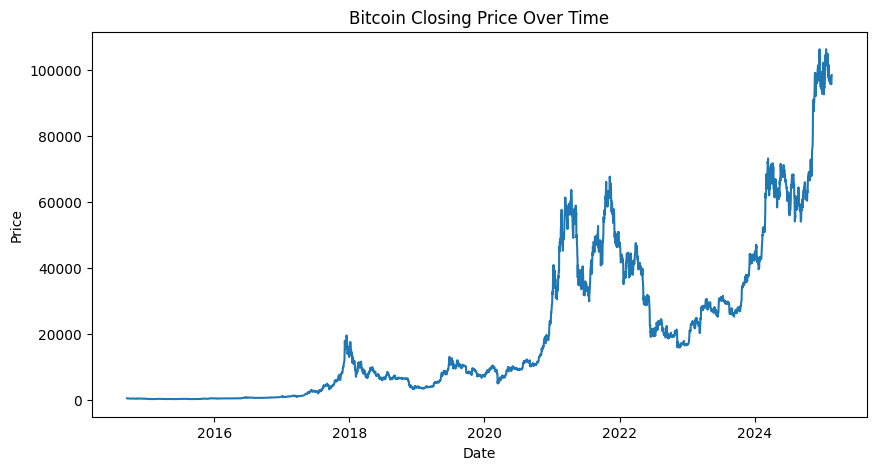

In [121]:
plt.figure(figsize=(10,5))
plt.plot(df['Close'])
plt.title("Bitcoin Closing Price Over Time")
plt.xlabel("Date")
plt.ylabel("Price")
plt.show()

**STEP 6: Feature Engineeging (Moving Average)**

In [112]:
# Remove commas and convert to float
df['Close'] = df['Close'].astype(str).str.replace(',', '')
df['Close'] = pd.to_numeric(df['Close'], errors='coerce')

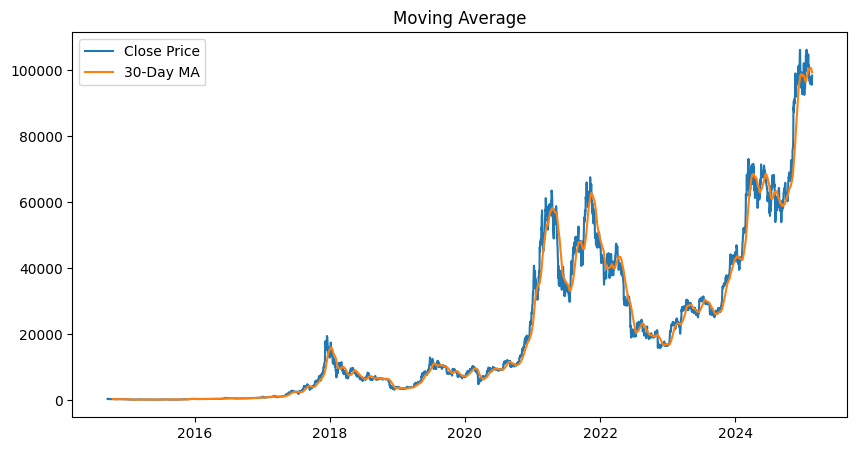

In [113]:
df['MA_30'] = df['Close'].rolling(window=30).mean()

plt.figure(figsize=(10,5))
plt.plot(df['Close'], label='Close Price')
plt.plot(df['MA_30'], label='30-Day MA')
plt.legend()
plt.title("Moving Average")
plt.show()

**STEP 7: Time Series Visualization**

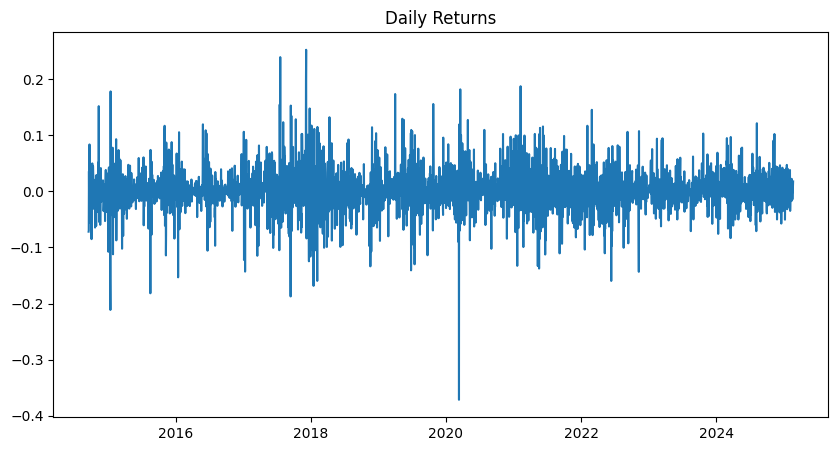

In [114]:
# Daily Returns
df['Daily_Return'] = df['Close'].pct_change()

plt.figure(figsize=(10,5))
plt.plot(df['Daily_Return'])
plt.title("Daily Returns")
plt.show()

**STEP 8: Building ARIMA Model**

In [115]:
data = df['Close']

model = ARIMA(data, order=(5,1,0))
model_fit = model.fit()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


**STEP 9: Forecasting Future Price**

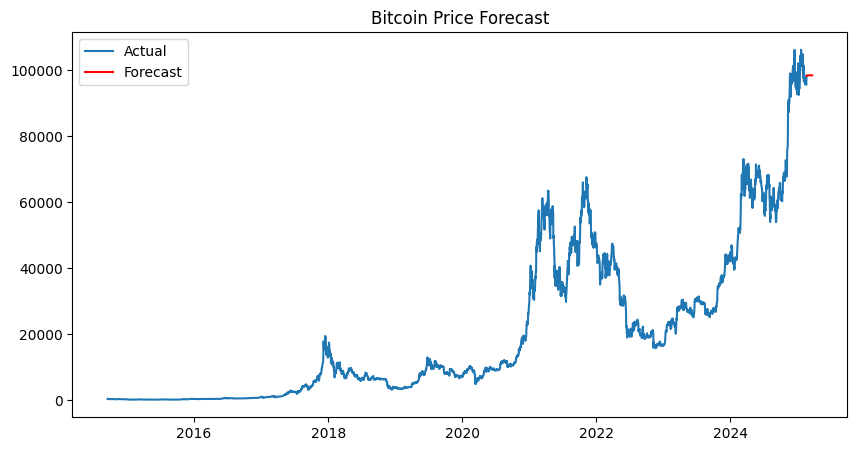

In [116]:
#Generate forecast
forecast = model_fit.forecast(steps=30)

# Create future dates
future_dates = pd.date_range(start=data.index[-1], periods=31, freq='D')[1:]

# Assign index to forecast
forecast.index = future_dates

# Plot
plt.figure(figsize=(10,5))
plt.plot(data, label='Actual')
plt.plot(forecast, label='Forecast', color='red')
plt.legend()
plt.title("Bitcoin Price Forecast")
plt.show()

**STEP 10: Model Evaluation (RMSE)**

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


RMSE: 7666.80901307063


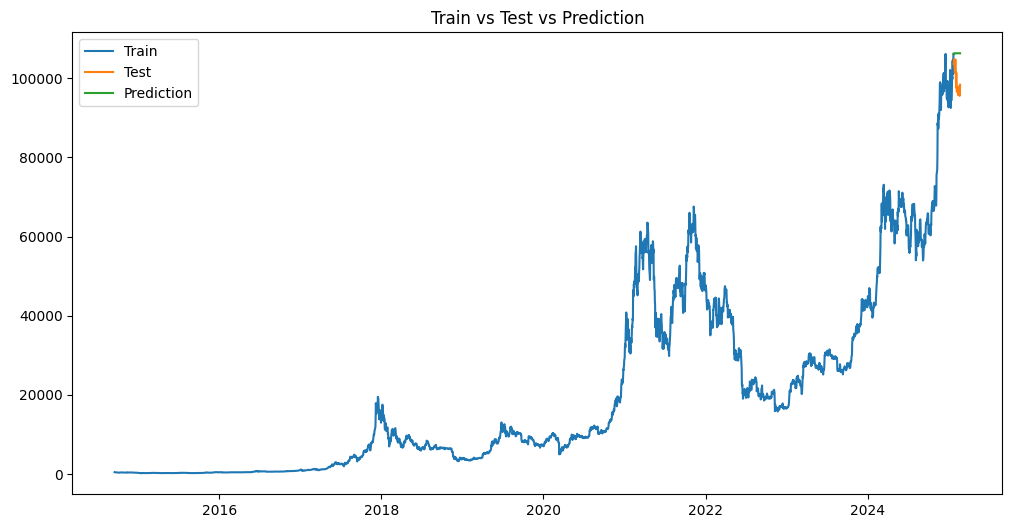

In [117]:
train = data[:-30]
test = data[-30:]

model = ARIMA(train, order=(5,1,0))
model_fit = model.fit()

pred = model_fit.forecast(30)

# Fix indexing issue
pred.index = test.index

rmse = np.sqrt(mean_squared_error(test, pred))
print("RMSE:", rmse)

plt.figure(figsize=(12,6))
plt.plot(train, label='Train')
plt.plot(test, label='Test')
plt.plot(pred, label='Prediction')
plt.legend()
plt.title("Train vs Test vs Prediction")
plt.show()

**STEP 11: Conclusion / Insights**

In [118]:
print("""
- Bitcoin shows high volatility
- Long-term trend is increasing
- Moving average helps smooth fluctuations
- ARIMA model predicts short-term trends
- RMSE used for evaluating model performance
""")


- Bitcoin shows high volatility
- Long-term trend is increasing
- Moving average helps smooth fluctuations
- ARIMA model predicts short-term trends
- RMSE used for evaluating model performance



In [119]:
df.to_csv('bitcoin_final.csv')

In [120]:
from google.colab import files
files.download('bitcoin_final.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>